## Practical Assessment Instructions

Run your code from top to bottom, in order, to make sure it works correctly.

If you run into errors, try restarting the kernel and clearing all outputs before running the code again.
This helps remove old variable values that may cause unexpected issues.
(Your code will not be deleted when you do this.)

You do not need to add new lines of code, except where import statements are required.

Simply fill in the blanks with the correct values.
### Module 1 to 4

Linear Regression Model

In [1]:
#import the 9 relevant libraries for the data processing and machine learning
#You need pandas, numpy, matplotlib, seaborn, sklearn: LineatRegression, 
#StandardScaler, train_test_split, mean_squared_error, r2_score

# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools from scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the dataset for car price
cars = pd.read_csv("Car_price.csv") 

In [22]:
# Explore the first 5 rows of the dataset
cars.head()

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,...,enginelocation_front,enginelocation_rear,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111.0,...,True,False,False,False,False,False,False,True,False,False
1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111.0,...,True,False,False,False,False,False,False,True,False,False
2,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154.0,...,True,False,False,False,False,False,False,True,False,False
3,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102.0,...,True,False,False,False,False,False,False,True,False,False
4,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115.0,...,True,False,False,False,False,False,False,True,False,False


In [4]:
# View data types and for missing data using info function
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [5]:
# View the statistics for the dataset with describe function
cars.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [6]:
# using a unique function to find out the unique values of car names
cars.CarName.unique()

array(['alfa-romero giulia', 'alfa-romero stelvio',
       'alfa-romero Quadrifoglio', 'audi 100 ls', 'audi 100ls',
       'audi fox', 'audi 5000', 'audi 4000', 'audi 5000s (diesel)',
       'bmw 320i', 'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'maxda rx3', 'maxda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda glc deluxe', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 

In [8]:
# Replace the column horsepower missing values with mean
cars['horsepower'].replace('?', np.nan)
cars['horsepower'] = cars['horsepower'].astype(float)
mean_horsepower = round(cars['horsepower'].mean(), 2)
cars['horsepower'].fillna(mean_horsepower)

0      111.0
1      111.0
2      154.0
3      102.0
4      115.0
       ...  
200    114.0
201    160.0
202    134.0
203    106.0
204    114.0
Name: horsepower, Length: 205, dtype: float64

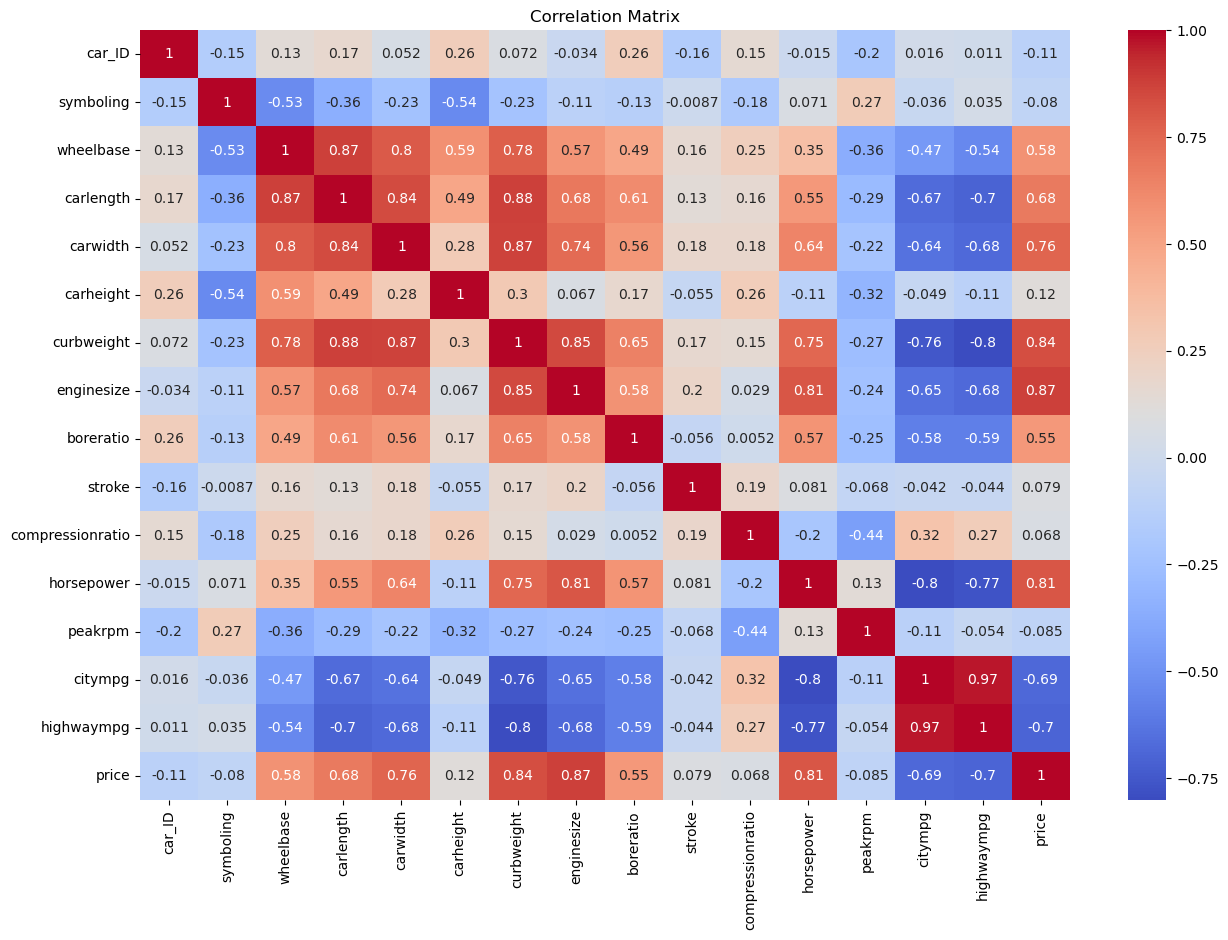

In [9]:
# Data exploration
# Build the Correlation matrix using only numeric columns
# First, select only numeric columns
numeric_cols = cars.select_dtypes(include=['int64', 'float64']).columns
cars_numeric = cars[numeric_cols]

# Now calculate correlation on numeric data only
corr = cars_numeric.corr()

# Create the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

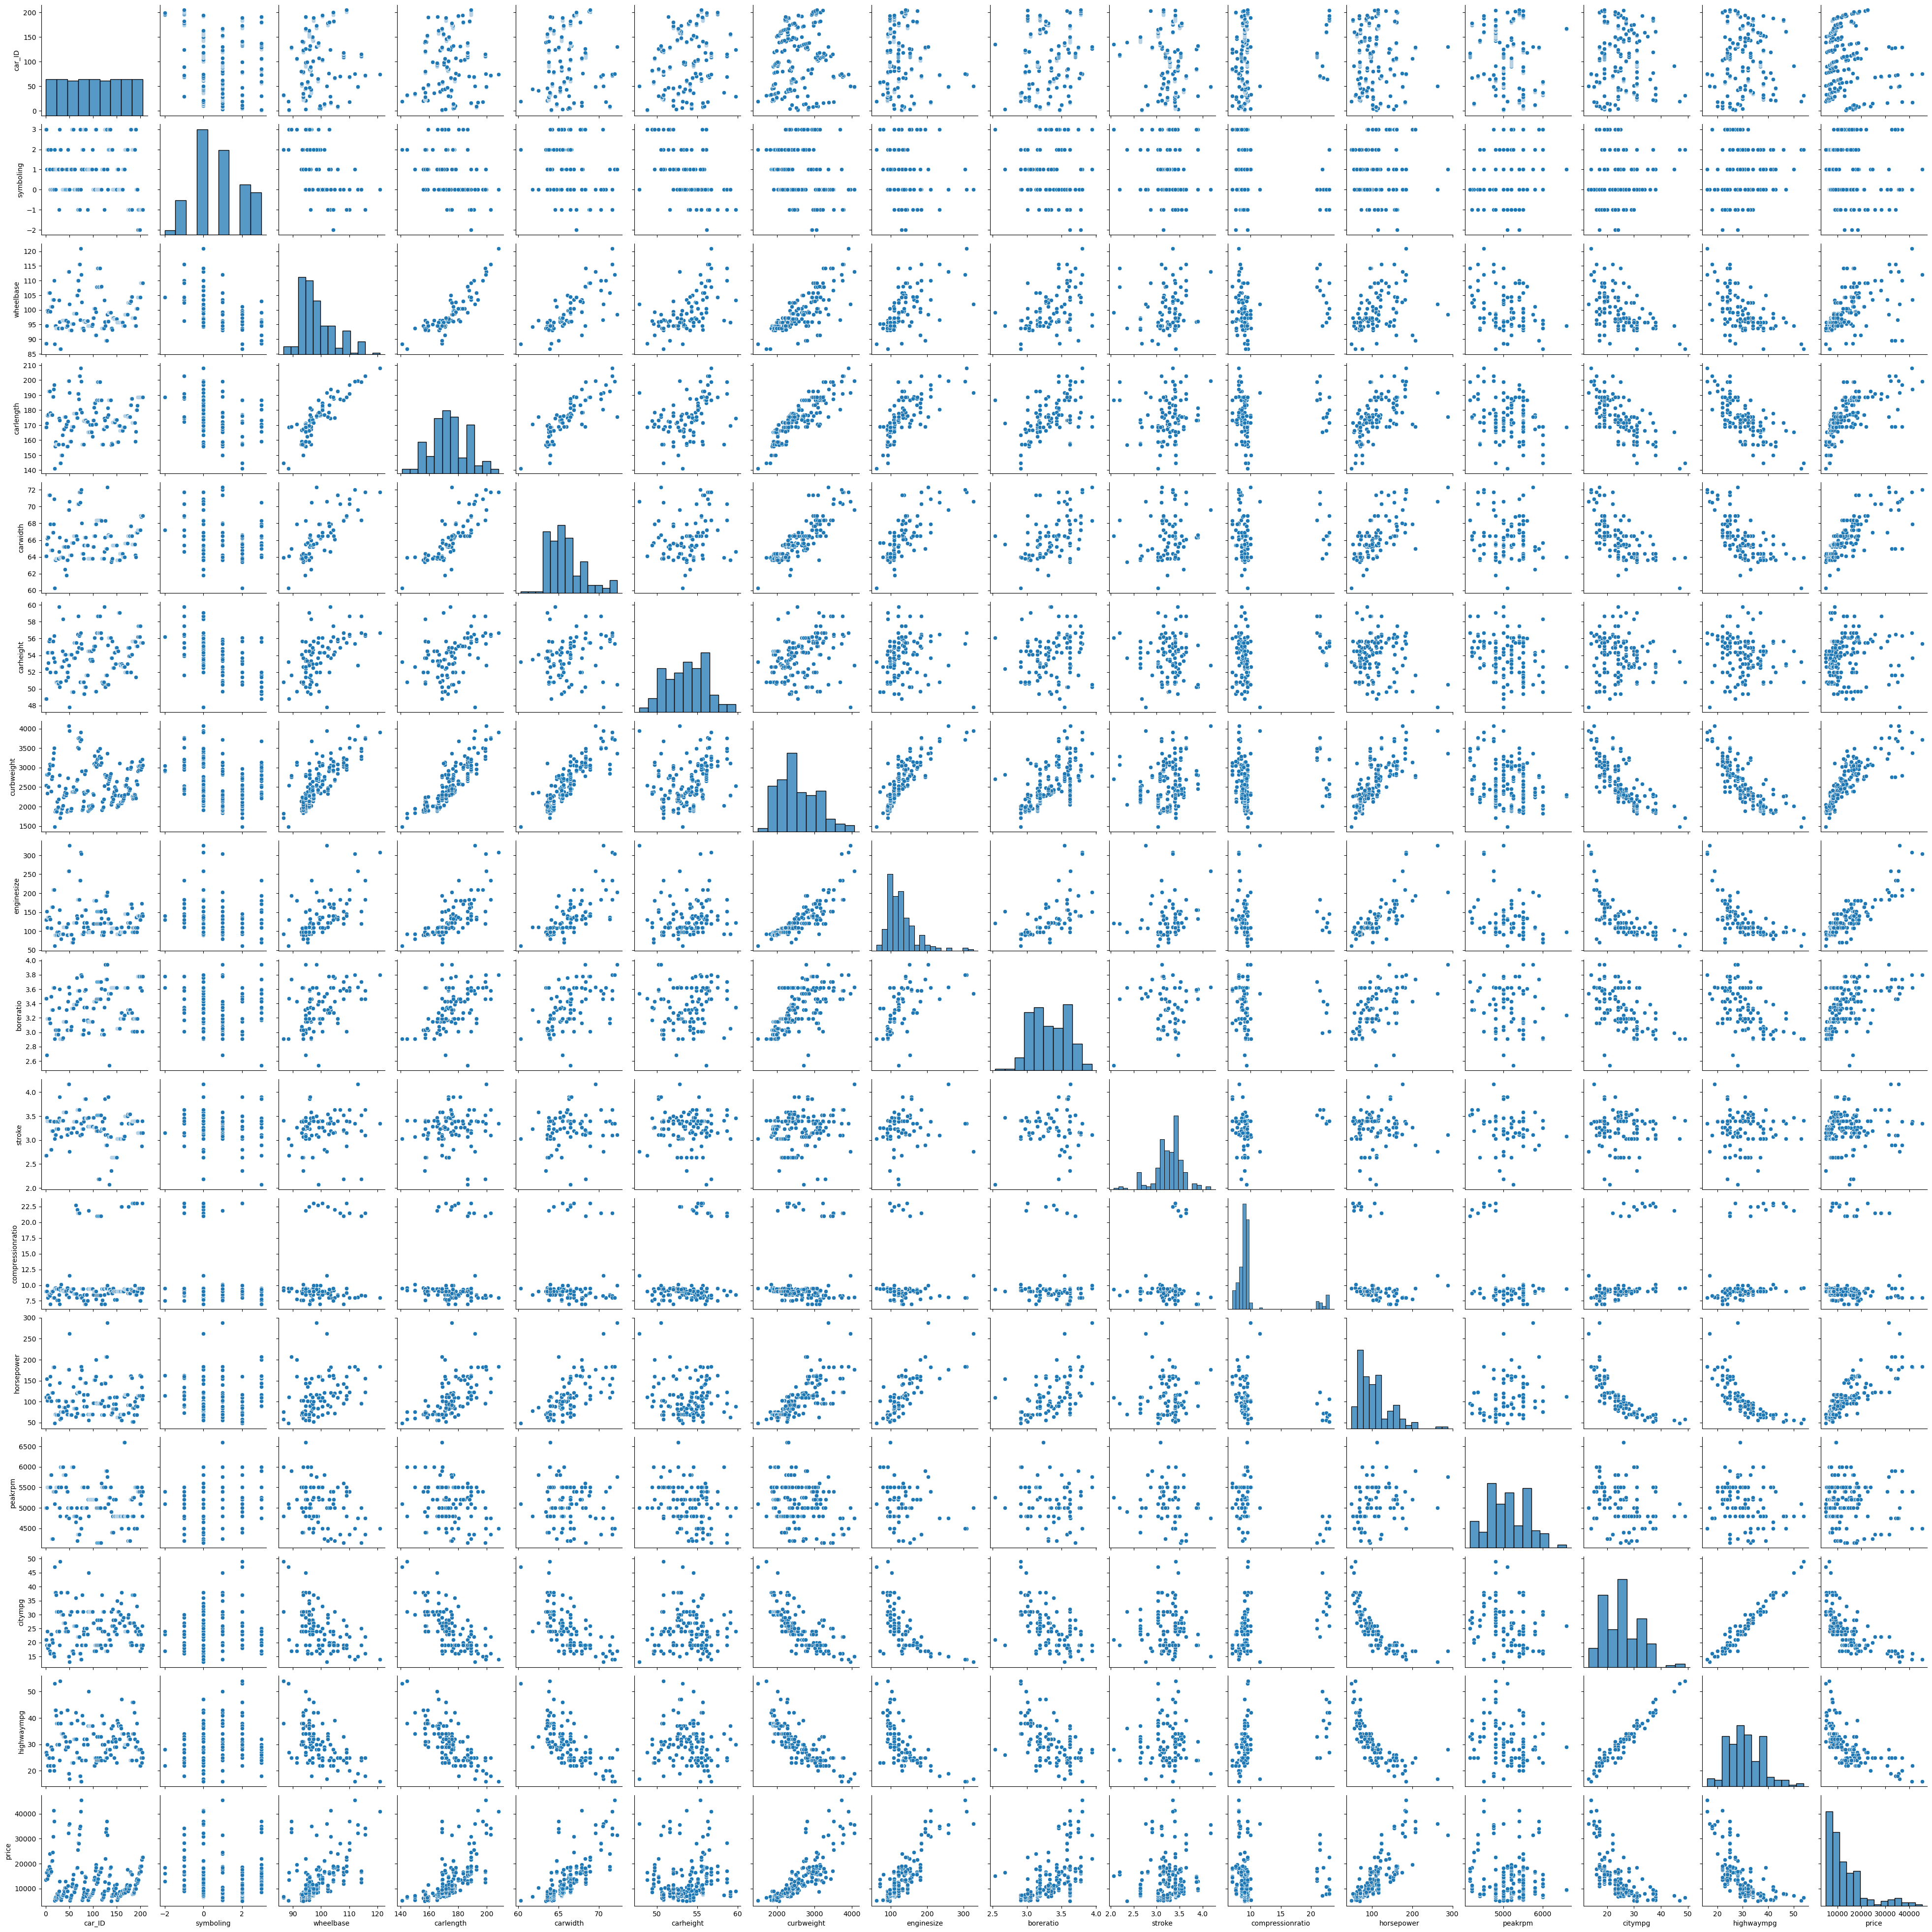

In [13]:
# Perform a Pairplot for cars datasets
sns.pairplot(cars)
plt.show()

In [14]:
# Data cleaning
# Remove irrelevant columns. There should be 3 columns that are not useful for machine learning
cars.drop(['car_ID', 'symboling', 'CarName'], axis=1, inplace=True)

In [15]:
#Add in the 'enginetype','fueltype','aspiration','carbody','cylindernumber','drivewheel','doornumber','enginelocation','fuelsystem' columns to transform into sig_cat_col
#Create dummy variables
sig_cat_col=['enginetype',
             'fueltype',
             'aspiration',
             'carbody',
             'cylindernumber',
             'drivewheel',
             'doornumber',
             'enginelocation',
             'fuelsystem']
dummy_variable=pd.get_dummies(cars[sig_cat_col])

In [16]:
#Concat the transformed columns and drop the original columns
cars=pd.concat([cars,dummy_variable],axis=1)
cars.drop(sig_cat_col,axis=1,inplace=True)

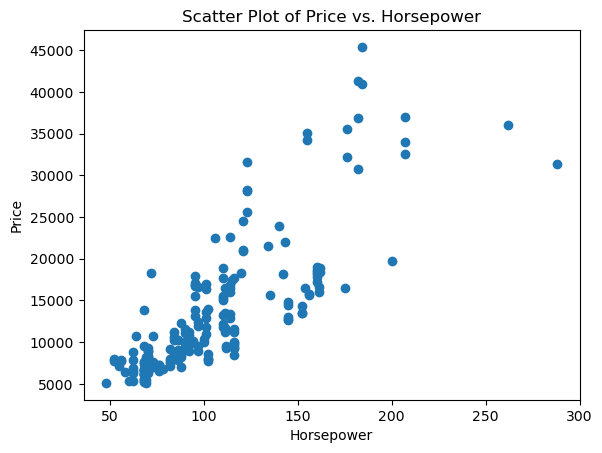

In [17]:
# Scatter plot of price vs. horsepower
plt.scatter(cars['horsepower'], cars['price'])
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.title('Scatter Plot of Price vs. Horsepower')
plt.show()

In [18]:
# Perform Train-test split. Understand which is the variable you want to predict to be used as Y 
X = cars.drop('price', axis=1)
y = cars['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [19]:
# Perform Feature scaling using standard scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# Perform Linear regression
lr = LinearRegression() #create the model
lr.fit(X_train, y_train) # train the model on training data
lr_pred = lr.predict(X_test) #predict on test data
lr_mse = mean_squared_error(y_test, lr_pred) # evaluated with MSE
lr_r2 = r2_score(y_test, lr_pred) #evaluate with R^2 score

In [21]:
#Print the results
print("Prediction Using Standard Scaling",lr_pred)
print("R2 Score Using Standard Scaling",lr_r2)
print('Mean Squared Error  Using Standard Scaling::', lr_mse)
print('Root Mean Squared Error  Using Standard Scaling::', np.sqrt(lr_mse))

Prediction Using Standard Scaling [ 5940.46000357 19818.60940506 15564.25332518 -1953.59971342
  9739.94226943 12602.23151231  6372.38906328  5807.6798559
 17046.65784532  7506.94471418 20007.36844985 34646.66051989
 12733.60931049 13985.63954437  6784.57924203 12411.54459641
 10053.19006148 19558.3350761   9351.90080811  6596.66900096
  9353.32021679 16521.05406403  9909.98268151 13154.21755227
 21188.46713775  6965.02485277  7682.13913773 16017.28041214
  6996.76912536  5855.487052    9640.12141956 10811.58861274
 17157.13495266  9784.57133247  6229.39165231 29051.761102
 12969.22826053 12402.69810119  5837.60513042 37626.45380832
  6474.46250296]
R2 Score Using Standard Scaling 0.8606736169333
Mean Squared Error  Using Standard Scaling:: 10786141.1812936
Root Mean Squared Error  Using Standard Scaling:: 3284.226116042195


### Module 5 to 7
Classification Models

In [1]:
# import the 14 relevant libraries for the data processing and machine learning
# You need pandas, numpy, matplotlib, seaborn, sklearn: load_iris, train_test_split, GridSearchCV, 
# DecisionTreeClassifier,LogisticRegression, KNeighborsRegression, accuracy_score, 
# confusion_matrix, classification_report, dataset: load_breast_cancer

# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools from scikit-learn
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier   
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset and assign the X data and Y labels
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [3]:
# Perform the Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Decision tree
dt = DecisionTreeClassifier()
params = {'criterion': ['gini', 'entropy'],
          'max_depth': range(1, 11)}
grid_search = GridSearchCV(estimator=dt, param_grid=params, cv=5)

grid_search.fit(X_train,y_train) # fit the model on training data

dt_pred = grid_search.predict(X_test) # predict on test data

#evaluate peformance
dt_acc = accuracy_score(y_test, dt_pred)
dt_cm = confusion_matrix(y_test, dt_pred)
dt_cr = classification_report(y_test, dt_pred)

In [5]:
# Logistic regression
lr = LogisticRegression()
params = {'penalty': ['l1', 'l2', 'elasticnet', 'none'],
          'C': np.logspace(-4, 4, 20),
          'solver': ['lbfgs', 'newton-cg', 'liblinear', 'sag' ,'saga']}

grid_search = GridSearchCV(estimator=lr, param_grid=params, cv=5)

#fit the model on training data
grid_search.fit(X_train, y_train)

#predict on test data
lr_pred = grid_search.predict(X_test)

#evaluate performance
lr_acc = accuracy_score(y_test, lr_pred)
lr_cm = confusion_matrix(y_test, lr_pred)
lr_cr = classification_report(y_test, lr_pred)

In [6]:
# KNN
knn = KNeighborsClassifier()
params = {'n_neighbors': range(1, 11)}
grid_search = GridSearchCV(estimator=knn, param_grid=params, cv=5)
grid_search.fit(X_train, y_train)
knn_pred = grid_search.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
knn_cm = confusion_matrix(y_test, knn_pred)
knn_cr = classification_report(y_test, knn_pred)

In [7]:
# Perform Model evaluation
print('Decision Tree:\n')
print(f'Accuracy: {dt_acc:.4f}\n')
print('Confusion matrix:\n', dt_cm)
print('\nClassification report:\n', dt_cr)

print('\nLogistic Regression:\n')
print(f'Accuracy: {lr_acc:.4f}\n')
print('Confusion matrix:\n', lr_cm)
print('\nClassification report:\n', lr_cr)

print('\nKNN:\n')
print(f'Accuracy: {knn_acc:.4f}\n')
print('Confusion matrix:\n', knn_cm)
print('\nClassification report:\n', knn_cr)


Decision Tree:

Accuracy: 0.9561

Confusion matrix:
 [[39  4]
 [ 1 70]]

Classification report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Logistic Regression:

Accuracy: 0.9825

Confusion matrix:
 [[42  1]
 [ 1 70]]

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


KNN:

Accuracy: 0.9561

Confusion matrix:
 [[39  4]
 [ 1 70]]

Classification report:
               precision    recall  f1-score   support

  

### End of Practical assessment
Please save your completed notebook and upload to the student portal. 